In [1]:
import sys
import os
os.chdir("/home/karlandersson/Programming/MasterThesisProject")
print(os.getcwd())

/home/karlandersson/Programming/MasterThesisProject


In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np

from utils.solver import Solver
from utils.iso_reactor_utils import generate_config_seq, generate_config
from utils.vapour_reactor_utils import plot_reactor_solutions

from coupled.vapour_reactor import VapourReactor

Mesh warning: N_Z changed from 50 to 46
Mesh warning: Neutronics N_Z changed from 50 to 30
Mesh warning: N_R changed from 15 to 65


In [7]:
with open("./data/reactor_data.json", "r") as f:
    data = json.load(f)
    data["HeatPipe"]["material"]["h_cond"] = 550

In [8]:
Ns = [15, 65, 40]
cfg = generate_config(data, *Ns)

reactor = VapourReactor(cfg)

solver = Solver([reactor])
solver.fsolve()

Mesh warning: N_Z changed from 40 to 46
Mesh warning: Fuel pin N_Z changed from 18 to 30
Mesh warning: Neutronics N_Z changed from 18 to 30
Solving Heat pipe initial values


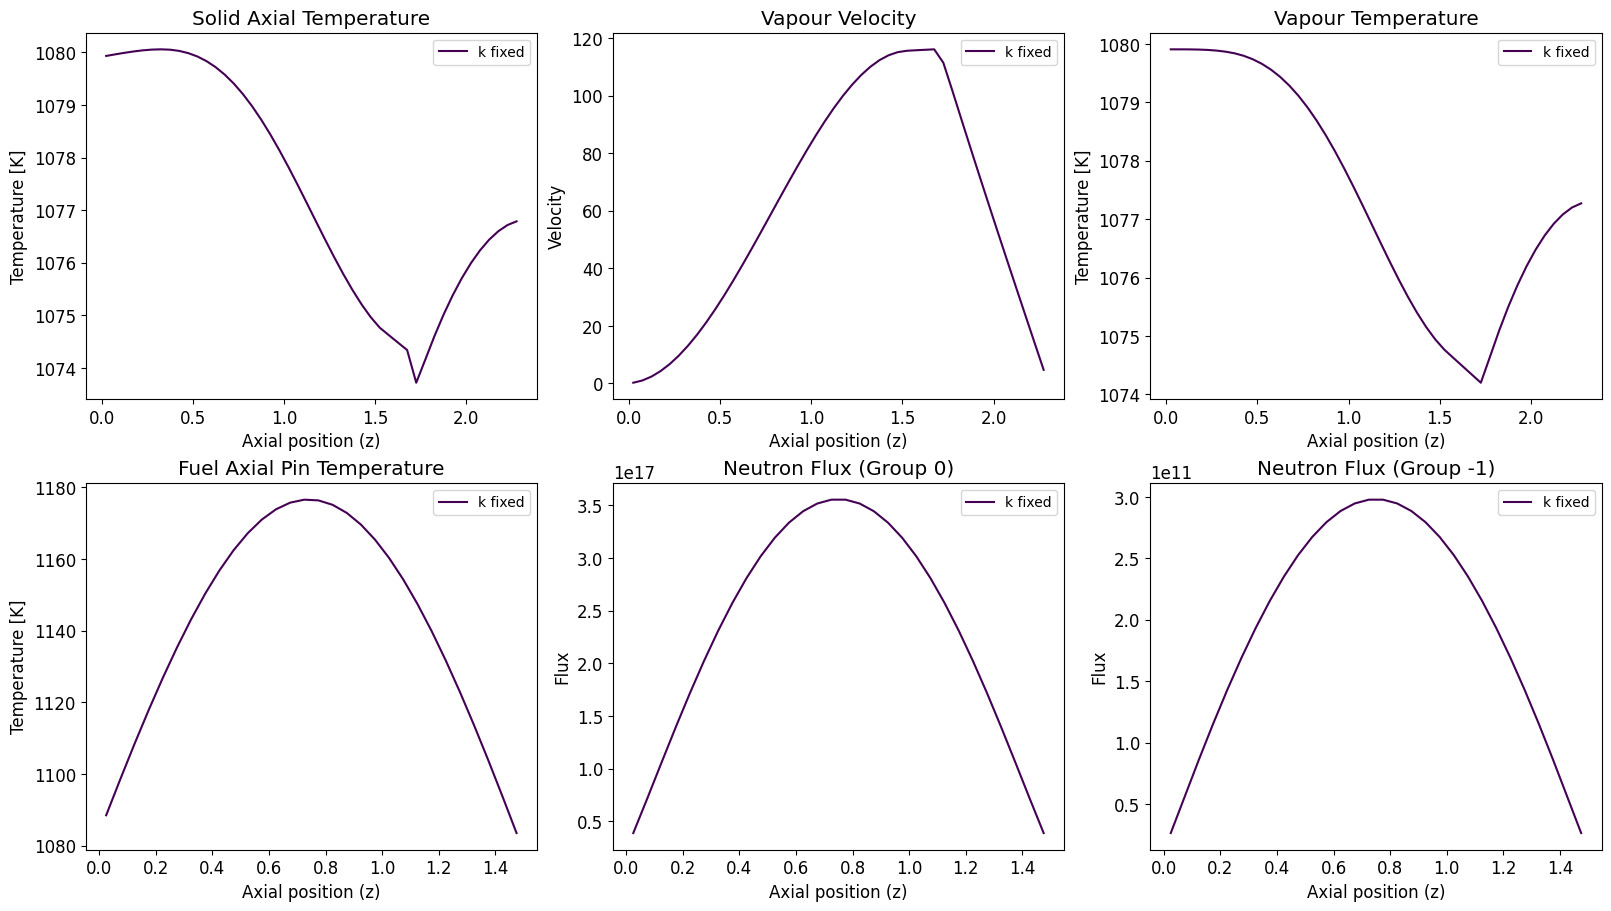

In [9]:
plot_reactor_solutions(solver)

In [6]:
((T_solid, u_v, T_v), T_FP, (phi_n_g, k)) = solver.solutions[0]

solved_reactor = solver.components[0]
Q_HP, _ = solved_reactor.calculate_HP_FP_boundary_cond(T_FP.reshape(-1), T_solid.reshape(-1))

print(np.sum(Q_HP))

17316.01731573776
